# MalBERT-XAI: Deployability Analysis
### Inference Time + Model Size + Memory

## Cell 1: Install

In [1]:
!pip install transformers torch psutil matplotlib seaborn -q
print('Dependencies ready!')

Dependencies ready!


## Cell 2: Mount Drive + Load Model

In [2]:
import os, re, json, time, random, warnings
import numpy as np
import pandas as pd
import psutil
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from datetime import datetime
from transformers import DistilBertTokenizerFast, DistilBertModel
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
warnings.filterwarnings("ignore")

from google.colab import drive
drive.mount("/content/drive", force_remount=True)

MODEL_PATH   = "/content/drive/MyDrive/00 MalBert - Internship Project/malbert_xai_models/best_model.pt"
DATASET_PATH = "/content/drive/MyDrive/00 MalBert - Internship Project/00_final_dataset_multiview.csv"
OUTPUT_DIR   = "/content/drive/MyDrive/00 MalBert - Internship Project/malbert_xai_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Checking files...")
for label, path in [("Model", MODEL_PATH), ("Dataset", DATASET_PATH)]:
    exists = os.path.exists(path)
    size   = f"({os.path.getsize(path)/1024/1024:.1f} MB)" if exists else ""
    print(f"  {label}: {'FOUND' if exists else 'NOT FOUND'} {size}")

class Config:
    BERT_MODEL="distilbert-base-uncased"; MAX_SEQ_LENGTH=512; HIDDEN_DIM=768
    FUSION_HEADS=8; FUSION_LAYERS=2; DROPOUT=0.3; SEED=42
    VIEWS=["PERM","API","INTENT","OPCODE"]; NUM_VIEWS=4; FAMILIES=[]; NUM_FAMILIES=0

random.seed(Config.SEED); np.random.seed(Config.SEED); torch.manual_seed(Config.SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nDevice: {device}")
if torch.cuda.is_available(): print(f"GPU: {torch.cuda.get_device_name(0)}")

print("\nLoading dataset...")
df = pd.read_csv(DATASET_PATH, encoding="latin-1", on_bad_lines="skip", engine="python")
if "text" in df.columns and "PERM" not in df.columns:
    def sv(t):
        if not isinstance(t,str): return {"PERM":"","API":"","INTENT":"","OPCODE":""}
        v={}
        for k,p in [("PERM",r"PERM:\s*(.*?)\s*API:"),("API",r"API:\s*(.*?)\s*INTENT:"),
                    ("INTENT",r"INTENT:\s*(.*?)\s*OPCODE:"),("OPCODE",r"OPCODE:\s*(.*)")]:
            m=re.search(p,t,re.DOTALL); v[k]=m.group(1).strip() if m else ""
        return v
    vd=df["text"].apply(sv).apply(pd.Series)
    df=pd.concat([df.drop(columns=["text"]),vd],axis=1)
df=df.drop(columns=[c for c in ["apk_size","permission_count","api_count","opcode_count","intent_count"] if c in df.columns])
df=df.dropna(subset=["family"])
df["family"]=df["family"].replace("Benign3","Benign")
df=df[df["family"].isin(["Banking","Riskware","SMS","Adware","Benign"])].reset_index(drop=True)
for v in Config.VIEWS:
    if v not in df.columns: df[v]=""
    df[v]=df[v].fillna("")
df["binary_label"]=(df["family"]!="Benign").astype(int)
le=LabelEncoder(); df["family_label"]=le.fit_transform(df["family"])
Config.FAMILIES=list(le.classes_); Config.NUM_FAMILIES=len(le.classes_)
label_encoder=le
_,test_df=train_test_split(df,test_size=0.2,random_state=42,stratify=df["family_label"])
print(f"Dataset: {len(df)} total, {len(test_df)} test samples")

class CrossAttentionFusion(nn.Module):
    def __init__(self, hidden_dim, num_heads, num_layers, dropout=0.1):
        super().__init__()
        enc_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim, nhead=num_heads, dim_feedforward=hidden_dim*4,
            dropout=dropout, activation="gelu", batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.view_position = nn.Parameter(torch.randn(1, Config.NUM_VIEWS, hidden_dim) * 0.02)
        self.attention_pool = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim//4), nn.Tanh(), nn.Linear(hidden_dim//4, 1))
        self.layer_norm = nn.LayerNorm(hidden_dim)

    def forward(self, x, return_attention=False):
        x = x + self.view_position
        x = self.transformer(x)
        w = F.softmax(self.attention_pool(x), dim=1)
        fused = self.layer_norm((x * w).sum(dim=1))
        return (fused, w.squeeze(-1)) if return_attention else fused

class MalBERTXAI(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.bert = DistilBertModel.from_pretrained(cfg.BERT_MODEL)
        self.view_projections = nn.ModuleDict({
            v: nn.Sequential(nn.Linear(cfg.HIDDEN_DIM, cfg.HIDDEN_DIM),
                             nn.LayerNorm(cfg.HIDDEN_DIM), nn.GELU(), nn.Dropout(cfg.DROPOUT))
            for v in cfg.VIEWS})
        self.fusion = CrossAttentionFusion(cfg.HIDDEN_DIM, cfg.FUSION_HEADS, cfg.FUSION_LAYERS, cfg.DROPOUT)
        self.binary_classifier = nn.Sequential(
            nn.Linear(cfg.HIDDEN_DIM, cfg.HIDDEN_DIM//2), nn.GELU(),
            nn.Dropout(cfg.DROPOUT), nn.Linear(cfg.HIDDEN_DIM//2, 2))
        self.family_classifier = nn.Sequential(
            nn.Linear(cfg.HIDDEN_DIM, cfg.HIDDEN_DIM//2), nn.GELU(),
            nn.Dropout(cfg.DROPOUT), nn.Linear(cfg.HIDDEN_DIM//2, cfg.NUM_FAMILIES))

    def encode_view(self, input_ids, attention_mask, view_name):
        return self.view_projections[view_name](
            self.bert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state[:, 0, :])

    def forward(self, batch, return_attention=False):
        embs = [self.encode_view(batch[f"{v}_input_ids"], batch[f"{v}_attention_mask"], v) for v in Config.VIEWS]
        stacked = torch.stack(embs, dim=1)
        if return_attention:
            fused, attn = self.fusion(stacked, return_attention=True)
            return self.binary_classifier(fused), self.family_classifier(fused), attn
        fused = self.fusion(stacked)
        return self.binary_classifier(fused), self.family_classifier(fused)

print("\nLoading model weights...")
model=MalBERTXAI(Config).to(device)
model.load_state_dict(torch.load(MODEL_PATH,map_location=device))
model.eval()
tokenizer=DistilBertTokenizerFast.from_pretrained(Config.BERT_MODEL)
print("Model loaded!")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Mounted at /content/drive
Checking files...
  Model: FOUND (319.2 MB)
  Dataset: FOUND (291.3 MB)

Device: cuda
GPU: Tesla T4

Loading dataset...
Dataset: 15644 total, 3129 test samples

Loading model weights...


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Model loaded!
Parameters: 83,652,872


## Cell 3: Model Size + Parameters

MODEL SIZE AND PARAMETER ANALYSIS

File Size:            319.2 MB
Total Parameters:     83,652,872
Trainable:            83,652,872

Component Breakdown:
  DistilBERT backbone          66,362,880  (79.3%)
  View projections (x4)         2,368,512  (2.8%)
  Cross-attn fusion            14,328,193  (17.1%)
  Binary classifier               296,066  (0.4%)
  Family classifier               297,221  (0.4%)

Vs Reference Paper:
  Our MalBERT-XAI               83.65M     319.2 MB
  DistilBERT ref                66.96M     255.4 MB
  TinyBERT                      14.35M      54.7 MB
  ALBERT                        11.69M      44.6 MB

Saving to: /content/drive/MyDrive/00 MalBert - Internship Project/malbert_xai_results/deployability_analysis


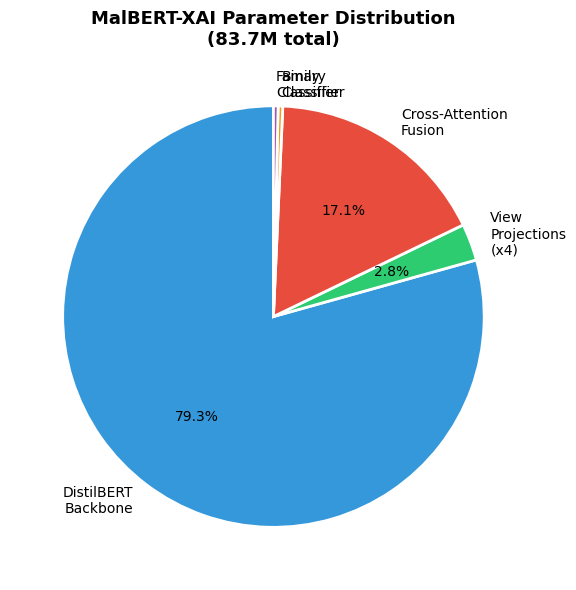

Saved: parameter_distribution.png


In [3]:
print("="*60+"\nMODEL SIZE AND PARAMETER ANALYSIS\n"+"="*60)
mfsz = os.path.getsize(MODEL_PATH)/(1024*1024)
total_params   = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
bert_params    = sum(p.numel() for p in model.bert.parameters())
proj_params   = sum(p.numel() for p in model.view_projections.parameters())
fusion_params  = sum(p.numel() for p in model.fusion.parameters())
binary_params = sum(p.numel() for p in model.binary_classifier.parameters())
family_params = sum(p.numel() for p in model.family_classifier.parameters())
print(f"\nFile Size:            {mfsz:.1f} MB")
print(f"Total Parameters:     {total_params:,}")
print(f"Trainable:            {trainable_params:,}")
print(f"\nComponent Breakdown:")
for nm, ct in [("DistilBERT backbone",bert_params),("View projections (x4)",proj_params),
               ("Cross-attn fusion",fusion_params),("Binary classifier",binary_params),("Family classifier",family_params)]:
    print(f"  {nm:<26s} {ct:>12,}  ({ct/total_params*100:.1f}%)")
print(f"\nVs Reference Paper:")
for nm, p, s in [("Our MalBERT-XAI",total_params,mfsz),("DistilBERT ref",66955010,255.4),("TinyBERT",14350874,54.7),("ALBERT",11685122,44.6)]:
    pc = f"{p/1e6:.2f}M" if isinstance(p,int) else p
    print(f"  {nm:<25s} {pc:>10s}  {s:>8.1f} MB")

# ── Create dedicated subfolder ──
DEPLOY_DIR = os.path.join(OUTPUT_DIR, "deployability_analysis")
os.makedirs(DEPLOY_DIR, exist_ok=True)
print(f"\nSaving to: {DEPLOY_DIR}")

# Pie chart
fig, ax = plt.subplots(figsize=(8, 6))
sizes  = [bert_params, proj_params, fusion_params, binary_params, family_params]
lbls   = ["DistilBERT\nBackbone", "View\nProjections\n(x4)", "Cross-Attention\nFusion",
          "Binary\nClassifier", "Family\nClassifier"]
colors = ["#3498DB", "#2ECC71", "#E74C3C", "#F39C12", "#9B59B6"]
ax.pie(sizes, labels=lbls, colors=colors,
       autopct=lambda p: f"{p:.1f}%" if p > 1 else "",
       startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 2})
ax.set_title(f"MalBERT-XAI Parameter Distribution\n({total_params/1e6:.1f}M total)",
             fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(DEPLOY_DIR, "parameter_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: parameter_distribution.png")
# fig,ax=plt.subplots(figsize=(8,6))
# sizes=[bert_params,proj_params,fusion_params,binary_params,family_params]
# lbls=["DistilBERT\nBackbone","View\nProjections\n(x4)","Cross-Attention\nFusion","Binary\nClassifier","Family\nClassifier"]
# colors=["#3498DB","#2ECC71","#E74C3C","#F39C12","#9B59B6"]
# ax.pie(sizes,labels=lbls,colors=colors,autopct=lambda p:f"{p:.1f}%" if p>1 else "",startangle=90,wedgeprops={"edgecolor":"white","linewidth":2})
# ax.set_title(f"MalBERT-XAI Parameter Distribution\n({total_params/1e6:.1f}M total)",fontweight="bold",fontsize=13)
# plt.tight_layout()
# plt.savefig(os.path.join(OUTPUT_DIR,"parameter_distribution.png"),dpi=150,bbox_inches="tight")
# plt.show()
# print("Saved: parameter_distribution.png")

## Cell 4: Inference Time

100 samples x 3 runs — mean and std.

INFERENCE TIME MEASUREMENT
Pre-tokenizing...
Done. 100 samples ready.

Warmup...
Warmup done.

Measuring (3 runs x 100 samples)...
  Run 1: mean = 58.80 ms
  Run 2: mean = 59.50 ms
  Run 3: mean = 60.12 ms

Results (300 measurements):
  Mean:     59.47 +/- 0.98 ms
  Min:      56.62 ms | Max: 63.20 ms
  95th pct: 61.29 ms
  Device:   cuda


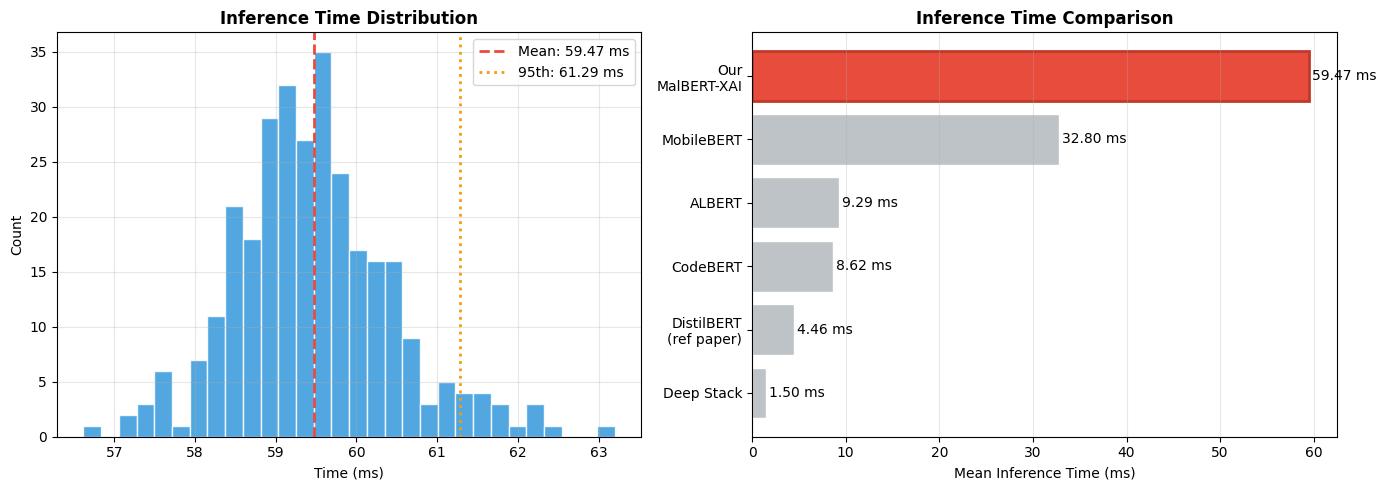

Saved: inference_time_analysis.png


In [4]:
print("="*60+"\nINFERENCE TIME MEASUREMENT\n"+"="*60)
NUM_SAMPLES=100; NUM_RUNS=3
sample_rows=test_df.sample(n=NUM_SAMPLES,random_state=42).reset_index(drop=True)
def tok(row):
    b={}
    for view in Config.VIEWS:
        text=row[view] if isinstance(row.get(view),str) else ""
        enc=tokenizer(text,max_length=512,padding="max_length",truncation=True,return_tensors="pt")
        b[f"{view}_input_ids"]=enc["input_ids"].to(device)
        b[f"{view}_attention_mask"]=enc["attention_mask"].to(device)
    b["binary_label"]=torch.tensor([0]).to(device)
    b["family_label"]=torch.tensor([0]).to(device)
    return b
print("Pre-tokenizing...")
tokenized_samples=[tok(sample_rows.iloc[i]) for i in range(NUM_SAMPLES)]
print(f"Done. {NUM_SAMPLES} samples ready.")
print("\nWarmup..."); model.eval()
with torch.no_grad():
    for b in tokenized_samples[:10]: _=model(b)
if device.type=="cuda": torch.cuda.synchronize()
print("Warmup done.")
print(f"\nMeasuring ({NUM_RUNS} runs x {NUM_SAMPLES} samples)...")
all_times=[]
for run in range(NUM_RUNS):
    rt=[]
    with torch.no_grad():
        for batch in tokenized_samples:
            if device.type=="cuda": torch.cuda.synchronize()
            s=time.perf_counter(); _=model(batch)
            if device.type=="cuda": torch.cuda.synchronize()
            rt.append((time.perf_counter()-s)*1000)
    print(f"  Run {run+1}: mean = {sum(rt)/len(rt):.2f} ms")
    all_times.extend(rt)
mean_time=np.mean(all_times); std_time=np.std(all_times)
min_time=np.min(all_times); max_time=np.max(all_times); p95_time=np.percentile(all_times,95)
print(f"\nResults ({NUM_SAMPLES*NUM_RUNS} measurements):")
print(f"  Mean:     {mean_time:.2f} +/- {std_time:.2f} ms")
print(f"  Min:      {min_time:.2f} ms | Max: {max_time:.2f} ms")
print(f"  95th pct: {p95_time:.2f} ms")
print(f"  Device:   {device}")
fig,axes=plt.subplots(1,2,figsize=(14,5))
axes[0].hist(all_times,bins=30,color="#3498DB",edgecolor="white",alpha=0.85)
axes[0].axvline(mean_time,color="#E74C3C",linewidth=2,linestyle="--",label=f"Mean: {mean_time:.2f} ms")
axes[0].axvline(p95_time,color="#F39C12",linewidth=2,linestyle=":",label=f"95th: {p95_time:.2f} ms")
axes[0].set_title("Inference Time Distribution",fontweight="bold")
axes[0].set_xlabel("Time (ms)"); axes[0].set_ylabel("Count"); axes[0].legend(); axes[0].grid(alpha=0.3)
rms=["Deep Stack","DistilBERT\n(ref paper)","CodeBERT","ALBERT","MobileBERT","Our\nMalBERT-XAI"]
rts=[1.50,4.46,8.62,9.29,32.80,mean_time]
bcs=["#BDC3C7"]*5+["#E74C3C"]
bars=axes[1].barh(rms,rts,color=bcs,edgecolor="white")
for bar,t in zip(bars,rts):
    axes[1].text(bar.get_width()+0.3,bar.get_y()+bar.get_height()/2,f"{t:.2f} ms",va="center",fontsize=10)
bars[-1].set_edgecolor("#C0392B"); bars[-1].set_linewidth(2)
axes[1].set_title("Inference Time Comparison",fontweight="bold"); axes[1].set_xlabel("Mean Inference Time (ms)"); axes[1].grid(alpha=0.3,axis="x")
plt.tight_layout()
plt.savefig(os.path.join(DEPLOY_DIR, "inference_time_analysis.png"), dpi=150, bbox_inches="tight")
plt.show(); print("Saved: inference_time_analysis.png")

## Cell 5: Peak Memory Usage

In [5]:
import gc, tracemalloc
print("="*60+"\nPEAK MEMORY USAGE\n"+"="*60)
if device.type=="cuda":
    torch.cuda.reset_peak_memory_stats(); torch.cuda.empty_cache()
    with torch.no_grad():
        for b in tokenized_samples[:20]: _=model(b)
    torch.cuda.synchronize()
    gpu_peak_mb=torch.cuda.max_memory_allocated()/(1024*1024)
    print(f"GPU Peak Allocated: {gpu_peak_mb:.1f} MB")
else:
    gpu_peak_mb=0; print("GPU: Not available")
process=psutil.Process(os.getpid()); gc.collect()
mb=process.memory_info().rss/(1024*1024)
tracemalloc.start()
with torch.no_grad():
    for b in tokenized_samples: _=model(b)
_,peak_t=tracemalloc.get_traced_memory(); tracemalloc.stop()
ma=process.memory_info().rss/(1024*1024); ram_delta_mb=ma-mb
print(f"\nCPU/RAM:")
print(f"  Before: {mb:.1f} MB | After: {ma:.1f} MB | Delta: {ram_delta_mb:.1f} MB")
model_memory_mb=sum(p.nelement()*p.element_size() for p in model.parameters())/(1024*1024)
buf_mb=sum(b.nelement()*b.element_size() for b in model.buffers())/(1024*1024)
total_model_mem=model_memory_mb+buf_mb
print(f"\nModel In-Memory Footprint:")
print(f"  Parameters (fp32): {model_memory_mb:.1f} MB")
print(f"  Total:             {total_model_mem:.1f} MB")
print(f"\nMemory Comparison:")
for nm,mem in [("Our MalBERT-XAI",f"{total_model_mem:.1f}"),("DistilBERT (ref)","275.8"),("CodeBERT","494.3"),("TinyBERT","71.7"),("MobileBERT","110.6")]:
    print(f"  {nm:<25s} {mem:>8s} MB")

PEAK MEMORY USAGE
GPU Peak Allocated: 352.6 MB

CPU/RAM:
  Before: 1617.3 MB | After: 1617.3 MB | Delta: 0.0 MB

Model In-Memory Footprint:
  Parameters (fp32): 319.1 MB
  Total:             319.1 MB

Memory Comparison:
  Our MalBERT-XAI              319.1 MB
  DistilBERT (ref)             275.8 MB
  CodeBERT                     494.3 MB
  TinyBERT                      71.7 MB
  MobileBERT                   110.6 MB


## Cell 6: Full Comparison Table + Chart

DEPLOYABILITY COMPARISON TABLE

  Model                    Acc%   AUC%      Time(ms)   Mem MB    Params
  --------------------------------------------------------------------
  Deep Stack               89.7   94.1    1.50+-0.15     16.3     0.59M
  Slim Emb                 90.5   95.7    1.53+-0.17     16.2     0.26M
  TinyBERT                 90.7   96.0    3.00+-0.18     71.7    14.35M
  DistilBERT (ref)         91.6   96.5    4.46+-0.43    275.8    66.96M
  ALBERT                   90.4   95.6    9.29+-0.60     66.2    11.69M
  CodeBERT                 91.1   96.3    8.62+-0.35    494.3   124.65M
  MobileBERT               85.8   92.4   32.80+-1.53    110.6    24.58M
  --------------------------------------------------------------------
  Our MalBERT-XAI         98.63  99.89   59.47+-0.98    319.1    83.65M  <- OURS


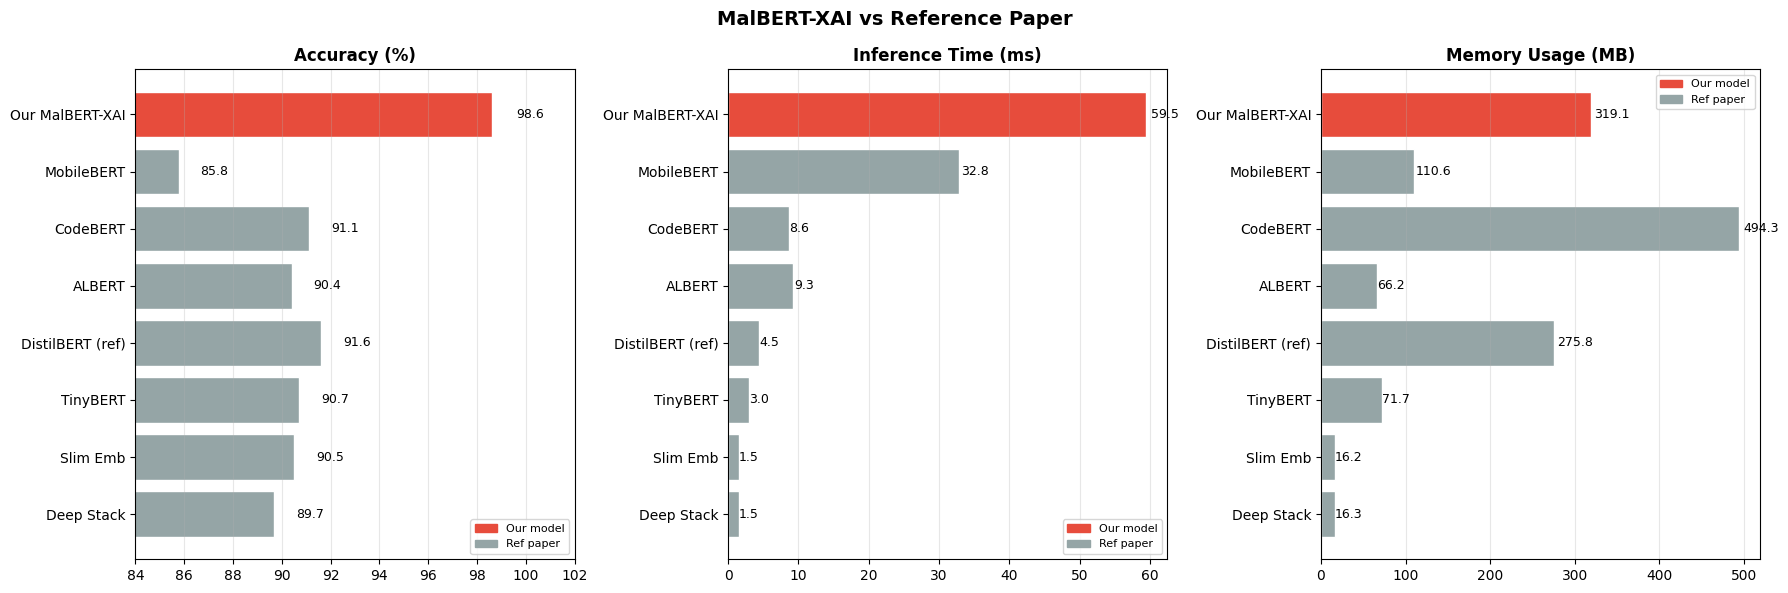

Saved: deployability_comparison.png


In [6]:
print("="*70+"\nDEPLOYABILITY COMPARISON TABLE\n"+"="*70)
our_accuracy=98.63; our_auc=99.89
ref_data=[
    {"M":"Deep Stack",       "A":89.7,"U":94.1,"T":1.50,"Ts":"1.50+-0.15", "Mem":16.3,  "P":"0.59M"},
    {"M":"Slim Emb",         "A":90.5,"U":95.7,"T":1.53,"Ts":"1.53+-0.17", "Mem":16.2,  "P":"0.26M"},
    {"M":"TinyBERT",         "A":90.7,"U":96.0,"T":3.00,"Ts":"3.00+-0.18", "Mem":71.7,  "P":"14.35M"},
    {"M":"DistilBERT (ref)", "A":91.6,"U":96.5,"T":4.46,"Ts":"4.46+-0.43", "Mem":275.8, "P":"66.96M"},
    {"M":"ALBERT",           "A":90.4,"U":95.6,"T":9.29,"Ts":"9.29+-0.60", "Mem":66.2,  "P":"11.69M"},
    {"M":"CodeBERT",         "A":91.1,"U":96.3,"T":8.62,"Ts":"8.62+-0.35", "Mem":494.3, "P":"124.65M"},
    {"M":"MobileBERT",       "A":85.8,"U":92.4,"T":32.80,"Ts":"32.80+-1.53","Mem":110.6, "P":"24.58M"},
]
print(f"\n  {'Model':<22s} {'Acc%':>6s} {'AUC%':>6s} {'Time(ms)':>13s} {'Mem MB':>8s} {'Params':>9s}")
print("  "+"-"*68)
for r in ref_data:
    print(f"  {r['M']:<22s} {r['A']:>6.1f} {r['U']:>6.1f} {r['Ts']:>13s} {r['Mem']:>8.1f} {r['P']:>9s}")
print("  "+"-"*68)
ts=f"{mean_time:.2f}+-{std_time:.2f}"
pp=f"{total_params/1e6:.2f}M"
print(f"  {'Our MalBERT-XAI':<22s} {our_accuracy:>6.2f} {our_auc:>6.2f} {ts:>13s} {total_model_mem:>8.1f} {pp:>9s}  <- OURS")
fig,axes=plt.subplots(1,3,figsize=(18,6))
ams=[r["M"] for r in ref_data]+["Our MalBERT-XAI"]
aac=[r["A"] for r in ref_data]+[our_accuracy]
atv=[r["T"] for r in ref_data]+[mean_time]
amm=[r["Mem"] for r in ref_data]+[total_model_mem]
bc=["#95A5A6"]*len(ref_data)+["#E74C3C"]
for ax,(vals,ttl,xl) in zip(axes,[(aac,"Accuracy (%)",(84,102)),(atv,"Inference Time (ms)",None),(amm,"Memory Usage (MB)",None)]):
    bars=ax.barh(ams,vals,color=bc,edgecolor="white")
    ax.set_title(ttl,fontweight="bold")
    if xl: ax.set_xlim(xl)
    for bar,v in zip(bars,vals):
        ax.text(bar.get_width()*1.01,bar.get_y()+bar.get_height()/2,f"{v:.1f}",va="center",fontsize=9)
    ax.grid(alpha=0.3,axis="x")
    ax.legend(handles=[mpatches.Patch(color="#E74C3C",label="Our model"),mpatches.Patch(color="#95A5A6",label="Ref paper")],fontsize=8)
plt.suptitle("MalBERT-XAI vs Reference Paper",fontweight="bold",fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(DEPLOY_DIR, "deployability_comparison.png"), dpi=150, bbox_inches="tight")
plt.show(); print("Saved: deployability_comparison.png")

## Cell 7: Save Results

In [7]:
results={
    "timestamp":datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "device":str(device),
    "model_file_size_mb":round(mfsz,2),
    "model_memory_mb":round(total_model_mem,2),
    "total_params":int(total_params),
    "component_params":{"distilbert":int(bert_params),"view_projections":int(proj_params),"fusion":int(fusion_params),"binary":int(binary_params),"family":int(family_params)},
    "inference_time_ms":{"mean":round(mean_time,3),"std":round(std_time,3),"min":round(min_time,3),"max":round(max_time,3),"p95":round(p95_time,3)},
    "memory_mb":{"gpu_peak":round(gpu_peak_mb,2),"cpu_delta":round(ram_delta_mb,2),"model_weights":round(total_model_mem,2)},
    "accuracy":{"binary_accuracy":our_accuracy,"binary_auc":our_auc}
}
sp = os.path.join(DEPLOY_DIR, "deployability_results.json")
with open(sp,"w") as f: json.dump(results,f,indent=2)
print(f"Saved: {sp}")
print("\n"+"="*60+"\nDEPLOYABILITY ANALYSIS COMPLETE\n"+"="*60)
print(f"  File Size:       {mfsz:.1f} MB")
print(f"  Parameters:      {total_params/1e6:.2f}M")
print(f"  Memory:          {total_model_mem:.1f} MB")
print(f"  Inference Time:  {mean_time:.2f} +/- {std_time:.2f} ms")
print(f"\n  vs DistilBERT (ref paper):")
print(f"  Accuracy: +{our_accuracy-91.6:.2f}% | AUC: +{our_auc-96.5:.2f}%")
print(f"  Time: ~{mean_time/4.46:.1f}x (expected: 4 views vs 1)")
print(f"\n  Plots saved to: {OUTPUT_DIR}")

Saved: /content/drive/MyDrive/00 MalBert - Internship Project/malbert_xai_results/deployability_analysis/deployability_results.json

DEPLOYABILITY ANALYSIS COMPLETE
  File Size:       319.2 MB
  Parameters:      83.65M
  Memory:          319.1 MB
  Inference Time:  59.47 +/- 0.98 ms

  vs DistilBERT (ref paper):
  Accuracy: +7.03% | AUC: +3.39%
  Time: ~13.3x (expected: 4 views vs 1)

  Plots saved to: /content/drive/MyDrive/00 MalBert - Internship Project/malbert_xai_results
